In [26]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
aapl = pd.read_csv("AAPL_stock.csv")
msft = pd.read_csv("MSFT_stock.csv")

In [28]:
df = pd.concat([aapl, msft])
df.head()

,date,open_price,high_price,low_price,close_price,volume,symbol
0,2026-03-05,260.79,261.555,257.25,260.29,49658626,AAPL
1,2026-03-04,264.65,266.150,261.42,262.52,39803119,AAPL
2,2026-03-03,263.48,265.560,260.13,263.75,38568921,AAPL
3,2026-03-02,262.41,266.530,260.20,264.72,41827946,AAPL
4,2026-02-27,272.81,272.810,262.89,264.18,72366505,AAPL


In [29]:
df.shape

(600, 7)

In [30]:
df["date"] = pd.to_datetime(df["date"])

cols = ["open_price","high_price","low_price","close_price","volume"]

for col in cols:
    df[col] = pd.to_numeric(df[col])

In [31]:
df = df.sort_values(["symbol","date"])

In [33]:
df["daily_return"] = df.groupby("symbol")["close_price"].pct_change()

In [34]:
df["MA_7"] = df.groupby("symbol")["close_price"].rolling(7).mean().reset_index(0,drop=True)

In [36]:
df.groupby("symbol")["daily_return"].mean()

symbol
AAPL    0.000692
AMZN    0.000324
MSFT   -0.001018
NVDA    0.000274
TSLA    0.000135
Name: daily_return, dtype: float64

In [37]:
df.groupby("symbol")["volume"].sum()

symbol
AAPL     4798323626
AMZN     4894299793
MSFT     5893881714
NVDA    18531477513
TSLA     7232640969
Name: volume, dtype: int64

In [38]:
df.groupby("symbol")["close_price"].max()

symbol
AAPL    286.19
AMZN    254.00
MSFT    542.07
NVDA    207.04
TSLA    489.88
Name: close_price, dtype: float64

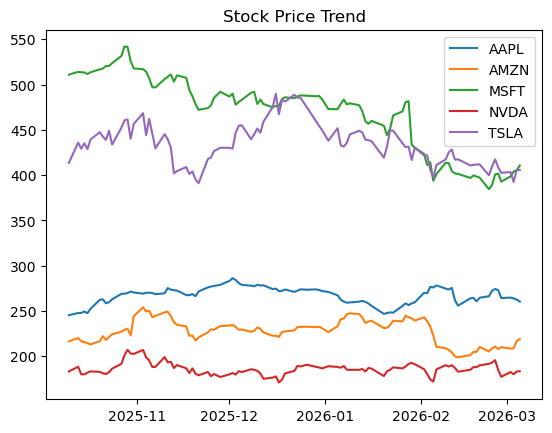

In [39]:
for stock in df["symbol"].unique():
    
    temp = df[df["symbol"] == stock]
    
    plt.plot(temp["date"], temp["close_price"], label=stock)

plt.legend()
plt.title("Stock Price Trend")
plt.show()

In [42]:
df.to_csv("stock_market_data.csv", index=False)

In [41]:
df.head()

,date,open_price,high_price,low_price,close_price,volume,symbol,daily_return,MA_7
99,2025-10-10,254.940,256.380,244.00,245.27,61999098,AAPL,NaN,NaN
98,2025-10-13,249.380,249.690,245.56,247.66,38142942,AAPL,0.009744,NaN
97,2025-10-14,246.600,248.845,244.70,247.77,35477986,AAPL,0.000444,NaN
96,2025-10-15,249.485,251.820,247.47,249.34,33893611,AAPL,0.006337,NaN
95,2025-10-16,248.250,249.040,245.13,247.45,39776974,AAPL,-0.007580,NaN
